In [1]:
import warnings
warnings.filterwarnings('ignore')

import scanpy as sc

import scvi
import torch

from BigSur.feature_selection import mcfano_feature_selection
import numpy as np
import pandas as pd
import seaborn as sns

import anndata

from matplotlib.colors import ListedColormap
from matplotlib import colormaps as cmaps

import sys
import os

import itertools

from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import linregress
from scipy.stats import median_abs_deviation

from scipy import stats

from matplotlib_venn import venn2

from collections import Counter

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 6

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
torch.set_float32_matmul_precision("high")

In [4]:
path_zero_ratio = f'/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_zero_ratio/bed_promoter_2000_8000/tko_zero_ratio_cutoffs.bed'

df_promoter_type = pd.read_csv(path_zero_ratio, sep='\t')

print(df_promoter_type)

      #chrom      start       stop    length strand      gene  Ratio Bivalent  \
0      chr19   50135466   50155466   16433.0      +     SCAF1          0.0000   
1       chr7  107291273  107311273   56979.0      +   SLC26A4          1.2530   
2      chr10   85944293   85964293   24157.0      +     CDHR1          1.0375   
3       chr3   23234818   23254818  388467.0      +    UBE2E2          0.5810   
4      chr15  101782253  101802253   76321.0      -     CHSY1          0.0000   
...      ...        ...        ...       ...    ...       ...             ...   
16389   chr5   33882095   33902095  368455.0      -  ADAMTS12          0.0000   
16390  chr17   26652787   26672787   11248.0      +   TNFAIP1          0.0000   
16391   chr1  151871987  151891987   38644.0      -     THEM4          0.0000   
16392  chr17    4796393    4816393    5327.0      -     CHRNE          0.0000   
16393  chr13  114135336  114155336   59208.0      +     TMCO3          0.0000   

       Ratio H3K27me3  Rati

In [5]:
# all differentiated cells

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/SRP261608/cellranger/SRR11789573_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger/RNA_DAY11_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger/RNA_DAY18_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger/RNA_DAY31_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE131736/cellranger/GSM3814885_day0_filtered_gene_bc_matrices_h5.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE131736/cellranger/GSM3814887_day6_filtered_gene_bc_matrices_h5.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE90553/data/GSM3039329_HUES-64-D6.h5ad'
    
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'Blastoid', 'NSC Day 11', 'NSC Day 18', 'NSC Day 31', 'EC Day 0', 'EC Day 6', 'Neural Day 6']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 2', 'Source 3', 'Source 3', 'Source 3', 'Source 4', 'Source 4', 'Source 5']
dataset='all_datasets_tko'

nsc_cmap = cm.get_cmap('Purples')
nsc_shades = [nsc_cmap(i) for i in [0.5, 0.7, 0.9]]  # Lighter to darker or vice versa
palette = list(cmaps['Paired'].colors[:6]) + nsc_shades + [mcolors.CSS4_COLORS['saddlebrown']] + [mcolors.CSS4_COLORS['orange']]

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                          sample_path   sample_name  \
0   /home/data/Shared/shared_datasets/sc_rna_seq/n...       WT Rep1   
1   /home/data/Shared/shared_datasets/sc_rna_seq/n...       WT Rep2   
2   /home/data/Shared/shared_datasets/sc_rna_seq/n...      TKO Rep1   
3   /home/data/Shared/shared_datasets/sc_rna_seq/n...      TKO Rep2   
4   /home/data/Shared/shared_datasets/sc_rna_seq/d...      Blastoid   
5   /home/data/Shared/shared_datasets/sc_rna_seq/d...    NSC Day 11   
6   /home/data/Shared/shared_datasets/sc_rna_seq/d...    NSC Day 18   
7   /home/data/Shared/shared_datasets/sc_rna_seq/d...    NSC Day 31   
8   /home/data/Shared/shared_datasets/sc_rna_seq/d...      EC Day 0   
9   /home/data/Shared/shared_datasets/sc_rna_seq/d...      EC Day 6   
10  /home/data/Shared/shared_datasets/sc_rna_seq/d...  Neural Day 6   

   sample_source  
0       Source 1  
1       Source 1  
2       Source 1  
3       Source 1  
4       Source 2  
5       Source 3  
6       Source

In [5]:
# ECs

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE131736/cellranger/GSM3814885_day0_filtered_gene_bc_matrices_h5.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE131736/cellranger/GSM3814886_day4_filtered_gene_bc_matrices_h5.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE131736/cellranger/GSM3814887_day6_filtered_gene_bc_matrices_h5.h5',
    
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'EC Day 0', 'EC Day 4', 'EC Day 6']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 2', 'Source 2', 'Source 2']
dataset='ec_tko'

palette = list(cmaps['Paired'].colors[:4]) + [mcolors.CSS4_COLORS['pink']] + [mcolors.CSS4_COLORS['hotpink']] + [mcolors.CSS4_COLORS['deeppink']]

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2      Source 1
4  /home/data/Shared/shared_datasets/sc_rna_seq/d...    EC Day 0      Source 2
5  /home/data/Shared/shared_datasets/sc_rna_seq/d...    EC Day 4      Source 2
6  /home/data/Shared/shared_datasets/sc_rna_seq/d...    EC Day 6      Source 2


In [184]:
# blastoid

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/SRP261608/cellranger/SRR11789573_count_hg19/outs/filtered_feature_bc_matrix.h5'
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'Blastoid']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 2']
dataset='blastoid_tko'

palette = list(cmaps['Paired'].colors[:4]) + [mcolors.CSS4_COLORS['saddlebrown']]

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2      Source 1
4  /home/data/Shared/shared_datasets/sc_rna_seq/d...    Blastoid      Source 2


In [4]:
# embryoid bodies

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE178274/data/EB',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
]
names = ['EB', 'WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2']
sources = ['Source 2', 'Source 1', 'Source 1', 'Source 1', 'Source 1']
dataset='embyroid_bodies_tko'

palette = [mcolors.CSS4_COLORS['saddlebrown']] + list(cmaps['Paired'].colors[:4])

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/d...          EB      Source 2
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1      Source 1
4  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2      Source 1


In [5]:
# tko/dko/wt

path_out_dir = 'figures'

paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/dko_atrinh_102022/cellranger/DKO_1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/dko_atrinh_102022/cellranger/DKO_2_count_hg19/outs/filtered_feature_bc_matrix.h5'
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'DKO Rep1', 'DKO Rep2']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 1']

palette = list(cmaps['Paired'].colors[:6])

# need to figure out which is correct
dataset='knockout_wt_tko_dko'

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2      Source 1
4  /home/data/Shared/shared_datasets/sc_rna_seq/n...    DKO Rep1      Source 1
5  /home/data/Shared/shared_datasets/sc_rna_seq/n...    DKO Rep2      Source 1


In [27]:
# wt/dko

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/dko_atrinh_102022/cellranger/DKO_1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/dko_atrinh_102022/cellranger/DKO_2_count_hg19/outs/filtered_feature_bc_matrix.h5'
]
names = ['WT Rep1', 'WT Rep2', 'DKO Rep1', 'DKO Rep2']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1']
dataset='dko'

palette = list(cmaps['Paired'].colors[:2]) + list(cmaps['Paired'].colors[4:6])

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...    DKO Rep1      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    DKO Rep2      Source 1


In [6]:
# nsc/tko

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger_with_bam/RNA_DAY4_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger_with_bam/RNA_DAY7_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger_with_bam/RNA_DAY11_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger_with_bam/RNA_DAY18_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/E-MTAB-12001/cellranger_with_bam/RNA_DAY31_SJ_S1_L001/outs/filtered_feature_bc_matrix.h5'
    
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'NSC Day 4', 'NSC Day 7', 'NSC Day 11', 'NSC Day 18', 'NSC Day 31']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 2', 'Source 2', 'Source 2', 'Source 2', 'Source 2']
dataset='nsc_tko'

nsc_cmap = cm.get_cmap('Purples')
nsc_shades = [nsc_cmap(i) for i in [0.1, 0.3, 0.5, 0.7, 0.9]]  # Lighter to darker or vice versa
palette = list(cmaps['Paired'].colors[:4]) + nsc_shades

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path sample_name sample_source
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep1      Source 1
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...     WT Rep2      Source 1
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep1      Source 1
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...    TKO Rep2      Source 1
4  /home/data/Shared/shared_datasets/sc_rna_seq/d...   NSC Day 4      Source 2
5  /home/data/Shared/shared_datasets/sc_rna_seq/d...   NSC Day 7      Source 2
6  /home/data/Shared/shared_datasets/sc_rna_seq/d...  NSC Day 11      Source 2
7  /home/data/Shared/shared_datasets/sc_rna_seq/d...  NSC Day 18      Source 2
8  /home/data/Shared/shared_datasets/sc_rna_seq/d...  NSC Day 31      Source 2


In [4]:
# other neural diff/tko

path_out_dir = 'figures'

# read data
paths = [
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_atrinh_112823/HUES64_WT_Rep2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO1_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/tko_atrinh_122923/TKO2_count_hg19/outs/filtered_feature_bc_matrix.h5',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE90553/data/GSM3039329_HUES-64-D6',
    '/home/data/Shared/shared_datasets/sc_rna_seq/data/GSE90553/data/GSM3039332_HUES-64-D14',
    
]
names = ['WT Rep1', 'WT Rep2', 'TKO Rep1', 'TKO Rep2', 'Neural Day 6', 'Neural Day 14']
sources = ['Source 1', 'Source 1', 'Source 1', 'Source 1', 'Source 2', 'Source 2']
dataset='other_neural_tko'

nsc_cmap = cm.get_cmap('Wistia')
nsc_shades = [nsc_cmap(i) for i in [0.2, 0.4]]  # Lighter to darker or vice versa
palette = list(cmaps['Paired'].colors[:4]) + nsc_shades

sample_info = pd.DataFrame({
    'sample_path': paths,
    'sample_name': names,
    'sample_source': sources
})

print(sample_info)

                                         sample_path    sample_name  \
0  /home/data/Shared/shared_datasets/sc_rna_seq/n...        WT Rep1   
1  /home/data/Shared/shared_datasets/sc_rna_seq/n...        WT Rep2   
2  /home/data/Shared/shared_datasets/sc_rna_seq/n...       TKO Rep1   
3  /home/data/Shared/shared_datasets/sc_rna_seq/n...       TKO Rep2   
4  /home/data/Shared/shared_datasets/sc_rna_seq/d...   Neural Day 6   
5  /home/data/Shared/shared_datasets/sc_rna_seq/d...  Neural Day 14   

  sample_source  
0      Source 1  
1      Source 1  
2      Source 1  
3      Source 1  
4      Source 2  
5      Source 2  


In [6]:
def plot_umap(adata, name, color, num_cells=None, viewing=True, **kwargs):
    
    if num_cells is not None:
        adata = sc.pp.subsample(adata, n_obs=num_cells, copy=True)

    if viewing:
        
        fig, ax = plt.subplots()
        fig.set_size_inches(10, 10)
        sc.pl.umap(adata, color=color, s=15, ax=ax, title=color, **kwargs)
        
        plt.show()
        
    else:
        
        fig, ax = plt.subplots()
        fig.set_size_inches(1, 1)
        sc.pl.umap(adata, color=color, s=1, ax=ax, title=color, **kwargs)

        path_out_dir = 'figures'
        path_svg = os.path.join(path_out_dir, f'umap_{name}_{color}.svg')
        fig.savefig(path_svg)
    

In [7]:
def plot_pca(adata, name, color, num_cells=None, viewing=True, **kwargs):
    
    if num_cells is not None:
        adata = sc.pp.subsample(adata, n_obs=num_cells, copy=True)

    if viewing:
        
        fig, ax = plt.subplots()
        fig.set_size_inches(10, 10)
        sc.pl.pca(adata, color=color, s=15, ax=ax, title=color, **kwargs)
        
        plt.show()
        
    else:
        
        fig, ax = plt.subplots()
        fig.set_size_inches(1, 1)
        sc.pl.pca(adata, color=color, s=1, ax=ax, title=color, **kwargs)

        path_out_dir = 'figures'
        path_svg = os.path.join(path_out_dir, f'pca_{name}_{color}.svg')
        fig.savefig(path_svg)

In [8]:
def get_log_odds(gene_subset, gene_set_1, all_genes_set):

    A = len(gene_subset & gene_set_1)  # Intersection
    B = len(gene_set_1 - gene_subset)  # Only in Gene Set 1
    C = len(gene_subset - gene_set_1)  # Only in PCA genes
    D = len(all_genes_set - (gene_subset | gene_set_1))  # Neither set

    odds_ratio, p_value = stats.fisher_exact([[A, B], [C, D]])

    log_odds_ratio = np.log(odds_ratio) if odds_ratio > 0 else float('-inf')

    return log_odds_ratio


In [9]:
def plot_top_n_strings(strings, n=10, title=None):
    # Count occurrences of each string
    counter = Counter(strings)
    
    # Get the top N most common strings
    most_common = counter.most_common(n)
    
    # Separate strings and their counts
    labels, counts = zip(*most_common)
    
    # Plot the results
    plt.bar(labels, counts)
    plt.xlabel("Strings")
    plt.ylabel("Counts")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.show()

In [10]:
def sc_preprocess(path: str, sample: str):

    if os.path.isdir(path):

        if os.path.exists(f'{path}/matrix.mtx.gz'):

             # this is basically only for the weird data... it is actually a large dataset, kinda nice to keep it gzipped
        
            adata = sc.read_mtx(f'{path}/matrix.mtx.gz')
            adata= adata.T
            
            adata_bc=pd.read_csv(f'{path}/barcodes.tsv.gz',header=None,sep='\t')
            adata_features=pd.read_csv(f'{path}/features.tsv.gz',header=None,sep='\t')
            
            adata.obs.index = adata_bc[0].tolist()
            adata.var.index = adata_features[0].tolist()
    
            adata.var['gene_ids'] = ''
            adata.var['feature_types'] = 'Gene Expression'
            adata.var['genome'] = 'hg38'
            
            path_met = f'{path}/cell_metadata.txt.gz'
            df_metadata = pd.read_csv(path_met, sep='\t')
            adata.obs['Reference_Annotation'] = df_metadata['Reference_Annotation']
            adata.obs['Seurat_Clusters_res.0.1'] = df_metadata['Seurat_Clusters_res.0.1']

        else:

            adata = sc.read_10x_mtx(path)
            adata.obs['Reference_Annotation'] = sample
            adata.obs['Seurat_Clusters_res.0.1'] = sample
            
    elif path.endswith('.h5ad'):
        adata = sc.read_h5ad(path)
        adata.obs['Reference_Annotation'] = sample
        adata.obs['Seurat_Clusters_res.0.1'] = sample
    else:
        adata = sc.read_10x_h5(path)
        adata.obs['Reference_Annotation'] = sample
        adata.obs['Seurat_Clusters_res.0.1'] = sample

    print(adata.obs)
    print(adata.var)
    
    adata.var_names_make_unique()

    # Generate qc metrics
    adata.var["mt"] = adata.var_names.str.startswith("MT-")

    sc.pp.calculate_qc_metrics(
        adata, 
        qc_vars=["mt"], 
        inplace=True, percent_top=[20], 
        log1p=True
        )
    
    print(path)
    sc.pl.violin(
        adata,
        ["log1p_total_counts", "log1p_n_genes_by_counts", "pct_counts_in_top_20_genes", "pct_counts_mt"],
        jitter=0.4,
        multi_panel=True,
    )
    
    # Identify outliers per qc metric
    adata.obs["counts_outlier"] = is_outlier(adata, "log1p_total_counts", 5)
    adata.obs["genes_outlier"] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
    adata.obs["topgenes_outlier"] = is_outlier(adata, "pct_counts_in_top_20_genes", 5)
    adata.obs["mito_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (adata.obs["pct_counts_mt"] <= 1)

    # Identify outliers based on ALL qc metrics 
    adata.obs["outlier"] = (
        adata.obs["counts_outlier"]  
        | adata.obs["genes_outlier"] 
        | adata.obs["topgenes_outlier"] 
        | adata.obs["mito_outlier"]
    )
    # Remove outliers
    adata = adata[~adata.obs["outlier"]].copy()
    
    # Remove non-developmental genes
    mt_genes = adata.var_names[adata.var_names.str.startswith('MT-')]
    rpl_genes = adata.var_names[adata.var_names.str.startswith('RPL')]
    rps_genes = adata.var_names[adata.var_names.str.startswith('RPS')]
    hist_genes = adata.var_names[adata.var_names.str.startswith('HIST')]
    rna_genes = adata.var_names[adata.var_names.str.startswith('RNA')]
    
    remove_genes = list(mt_genes) + list(rpl_genes) + list(rps_genes) + list(hist_genes) + list(rna_genes)
    adata = adata[:, ~adata.var_names.isin(remove_genes)]

    # Perform gene filtering
    sc.pp.filter_genes(adata, min_cells=3)

    # doublets
    sc.pp.scrublet(adata)
    
    adata.layers["counts"] = adata.X.copy()  # preserve counts

    return adata

# our outlier detection function from before
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
            np.median(M) + nmads * median_abs_deviation(M) < M
    )
    
    print(f'{metric}: {np.median(M) - nmads * median_abs_deviation(M)} - {np.median(M) + nmads * median_abs_deviation(M)}')
    
    return outlier

In [11]:
#####################
# LOAD PROCESSED DATA
#####################

fn = f'/home/data/nlaszik/h5ad/scvi_integrated_{dataset}.h5ad'
adata_concat = sc.read_h5ad(fn)


Reading WT Rep1
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGACGACGT-1              WT Rep1                 WT Rep1
AAACCCATCATCGCTC-1              WT Rep1                 WT Rep1
AAACCCATCTCATTAC-1              WT Rep1                 WT Rep1
AAACGAAAGTGGTTCT-1              WT Rep1                 WT Rep1
AAACGAACACATGAAA-1              WT Rep1                 WT Rep1
...                                 ...                     ...
TTTGTTGAGGAAGAAC-1              WT Rep1                 WT Rep1
TTTGTTGCAGAATTCC-1              WT Rep1                 WT Rep1
TTTGTTGCAGAGATTA-1              WT Rep1                 WT Rep1
TTTGTTGTCCCGTGAG-1              WT Rep1                 WT Rep1
TTTGTTGTCGACGATT-1              WT Rep1                 WT Rep1

[4102 rows x 2 columns]
                   gene_ids    feature_types genome
DDX11L1     ENSG00000223972  Gene Expression   hg19
WASH7P      ENSG00000227232  Gene Expression   hg19
MIR1302-10  ENSG00000243485  Gene 

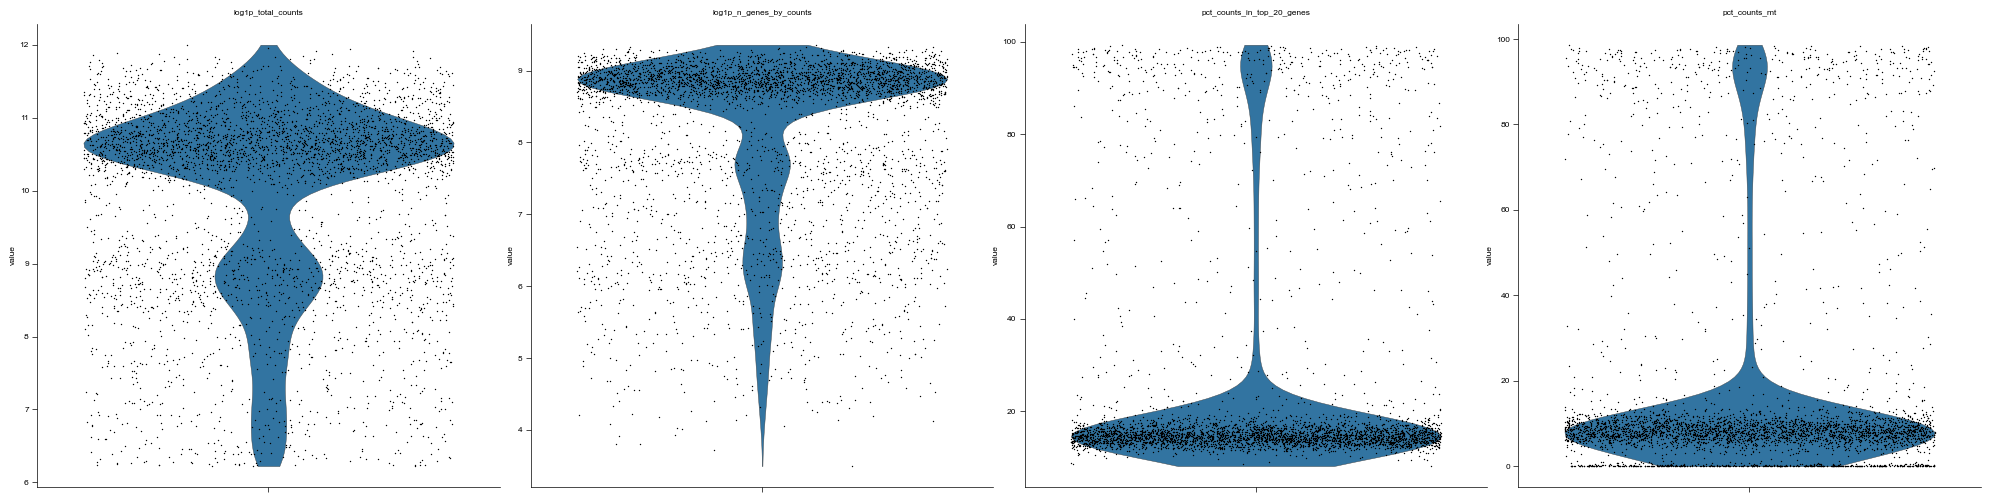

log1p_total_counts: 8.039750099182129 - 12.939127922058105
log1p_n_genes_by_counts: 7.594336160513448 - 9.94948968580861
pct_counts_in_top_20_genes: 7.640623793404419 - 22.117540421846737
pct_counts_mt: 1.7775516510009766 - 14.743427276611328

Reading WT Rep2
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGACGCCCT-1              WT Rep2                 WT Rep2
AAACCCACAGCTACCG-1              WT Rep2                 WT Rep2
AAACCCAGTACGGGAT-1              WT Rep2                 WT Rep2
AAACCCAGTAGGGAGG-1              WT Rep2                 WT Rep2
AAACCCATCCACTTTA-1              WT Rep2                 WT Rep2
...                                 ...                     ...
TTTGGTTCAACAGCCC-1              WT Rep2                 WT Rep2
TTTGGTTGTCTTTATC-1              WT Rep2                 WT Rep2
TTTGGTTGTGCTCCGA-1              WT Rep2                 WT Rep2
TTTGGTTGTTGCGGCT-1              WT Rep2                 WT Rep2
TTTGTTGTCCTTCTAA-1              WT R

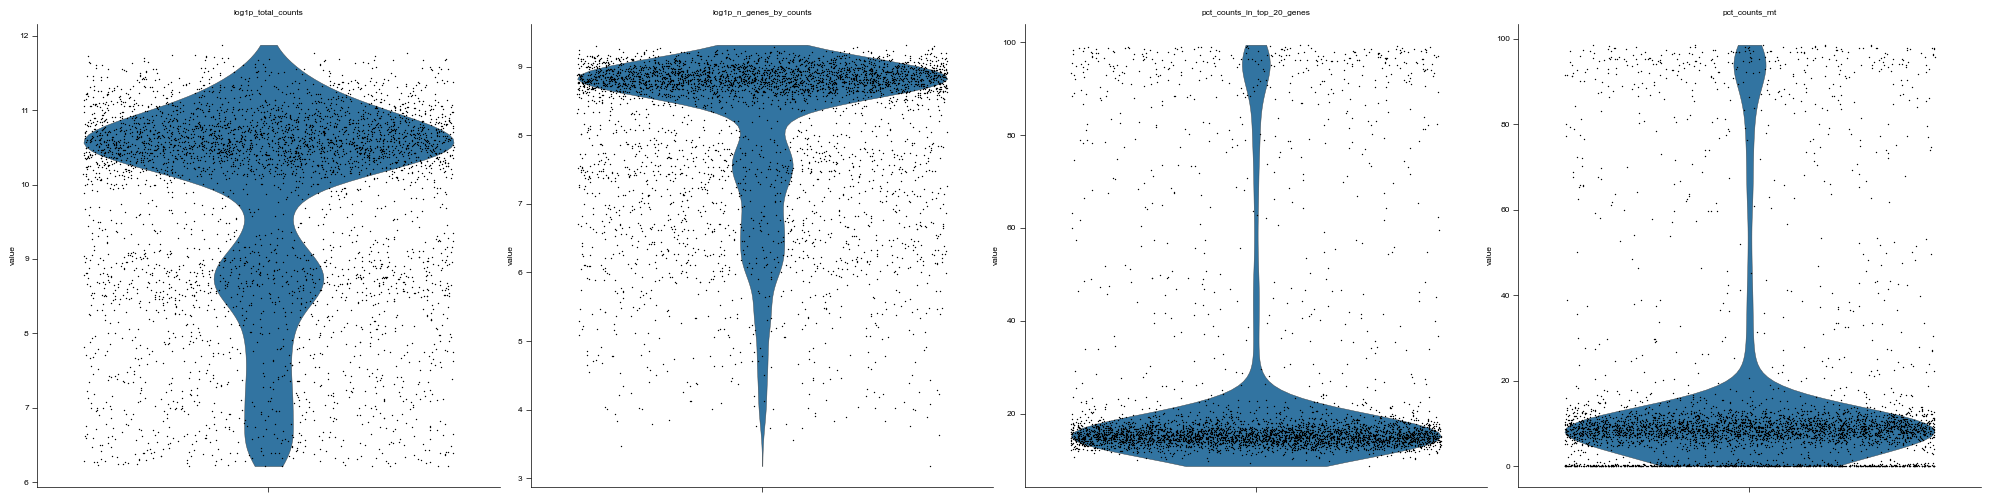

log1p_total_counts: 7.705276012420654 - 13.058292865753174
log1p_n_genes_by_counts: 7.399172928254679 - 10.028812599780768
pct_counts_in_top_20_genes: 8.058937445216914 - 22.954753254505036
pct_counts_mt: 1.3697490692138672 - 15.977720260620117

Reading TKO Rep1
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGTTCATCG-1             TKO Rep1                TKO Rep1
AAACCCATCGCATTGA-1             TKO Rep1                TKO Rep1
AAACCCATCTTCGGTC-1             TKO Rep1                TKO Rep1
AAACGAAAGAGCCATG-1             TKO Rep1                TKO Rep1
AAACGAAAGGAGATAG-1             TKO Rep1                TKO Rep1
...                                 ...                     ...
TTTGGTTTCTGGTCAA-1             TKO Rep1                TKO Rep1
TTTGTTGAGTAGCTCT-1             TKO Rep1                TKO Rep1
TTTGTTGCACTGATTG-1             TKO Rep1                TKO Rep1
TTTGTTGTCCGAAGGA-1             TKO Rep1                TKO Rep1
TTTGTTGTCGTTCTCG-1             TK

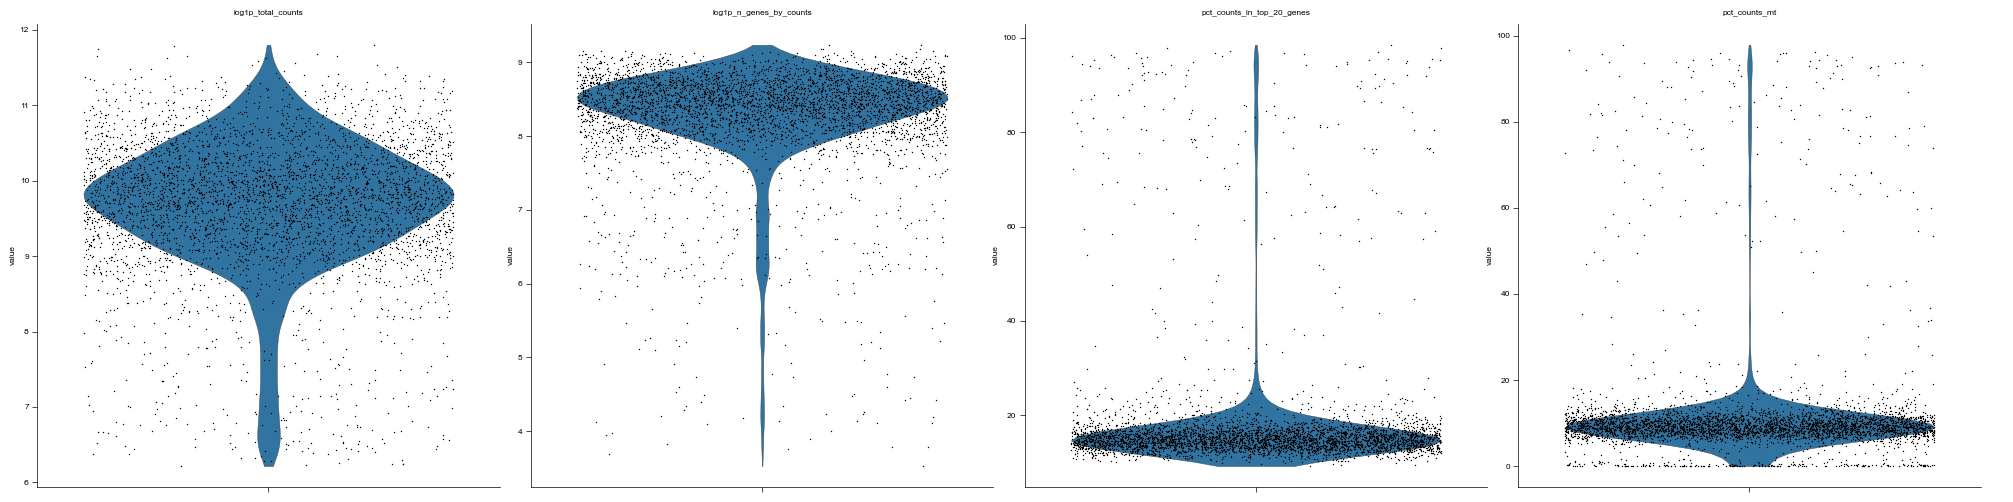

log1p_total_counts: 7.391244888305664 - 12.144777297973633
log1p_n_genes_by_counts: 7.165770789453202 - 9.712260031251226
pct_counts_in_top_20_genes: 7.503221065811939 - 22.293062793601536
pct_counts_mt: 4.491055488586426 - 13.776442527770996

Reading TKO Rep2
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGCTAAACA-1             TKO Rep2                TKO Rep2
AAACCCAAGTTTAGGA-1             TKO Rep2                TKO Rep2
AAACCCACAATCCTAG-1             TKO Rep2                TKO Rep2
AAACCCAGTACAGCGA-1             TKO Rep2                TKO Rep2
AAACCCAGTGACAGGT-1             TKO Rep2                TKO Rep2
...                                 ...                     ...
TTTGTTGGTATGCAAA-1             TKO Rep2                TKO Rep2
TTTGTTGGTATGGAGC-1             TKO Rep2                TKO Rep2
TTTGTTGGTGATGGCA-1             TKO Rep2                TKO Rep2
TTTGTTGTCCAAGGGA-1             TKO Rep2                TKO Rep2
TTTGTTGTCCGAGATT-1             TKO 

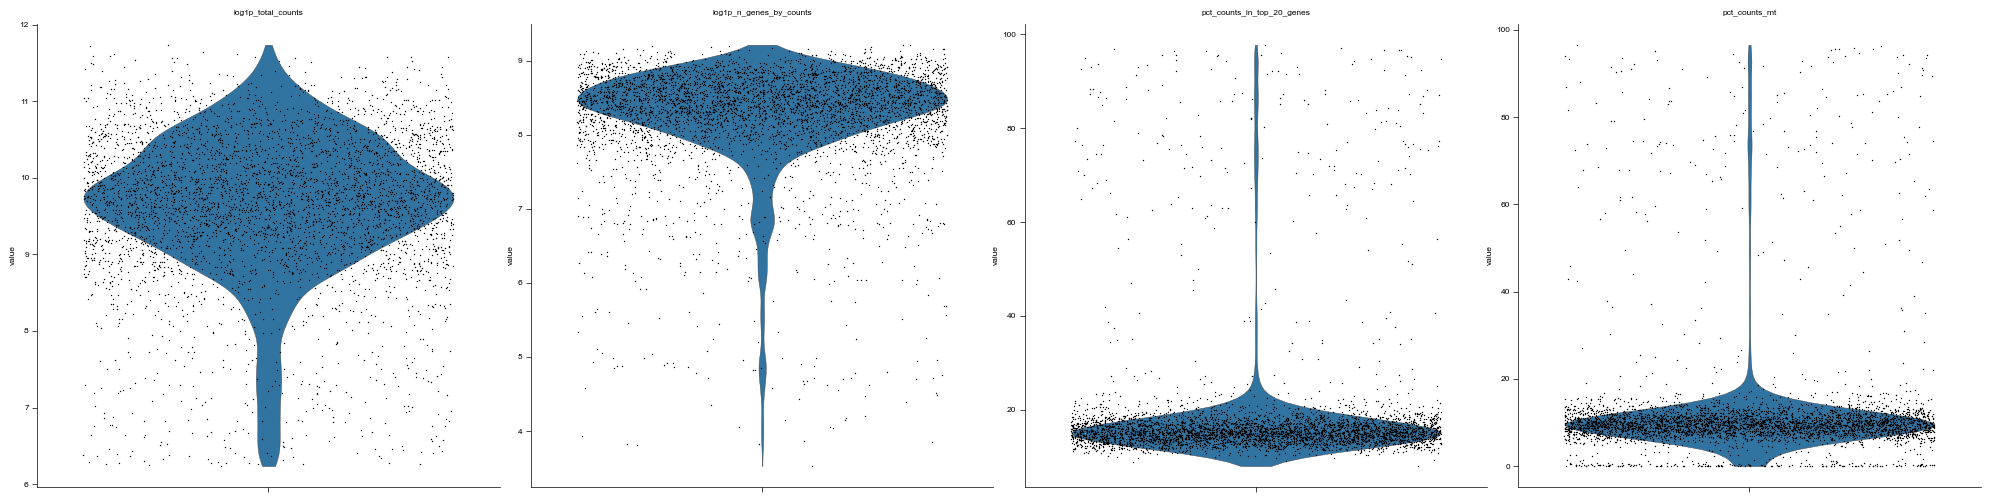

log1p_total_counts: 7.083519458770752 - 12.372783184051514
log1p_n_genes_by_counts: 7.037207621106149 - 9.801953103992325
pct_counts_in_top_20_genes: 7.385551360155195 - 23.0855838025124
pct_counts_mt: 4.636226654052734 - 14.451412200927734

Reading DKO Rep1
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGTTAACGA-1             DKO Rep1                DKO Rep1
AAACCCACACCTGCGA-1             DKO Rep1                DKO Rep1
AAACCCACACGCGCTA-1             DKO Rep1                DKO Rep1
AAACCCACATCCTCAC-1             DKO Rep1                DKO Rep1
AAACCCAGTAGCCAGA-1             DKO Rep1                DKO Rep1
...                                 ...                     ...
TTTGTTGGTTGGTAGG-1             DKO Rep1                DKO Rep1
TTTGTTGTCACTGTCC-1             DKO Rep1                DKO Rep1
TTTGTTGTCCAACACA-1             DKO Rep1                DKO Rep1
TTTGTTGTCCATTGGA-1             DKO Rep1                DKO Rep1
TTTGTTGTCCCGAGGT-1             DKO Re

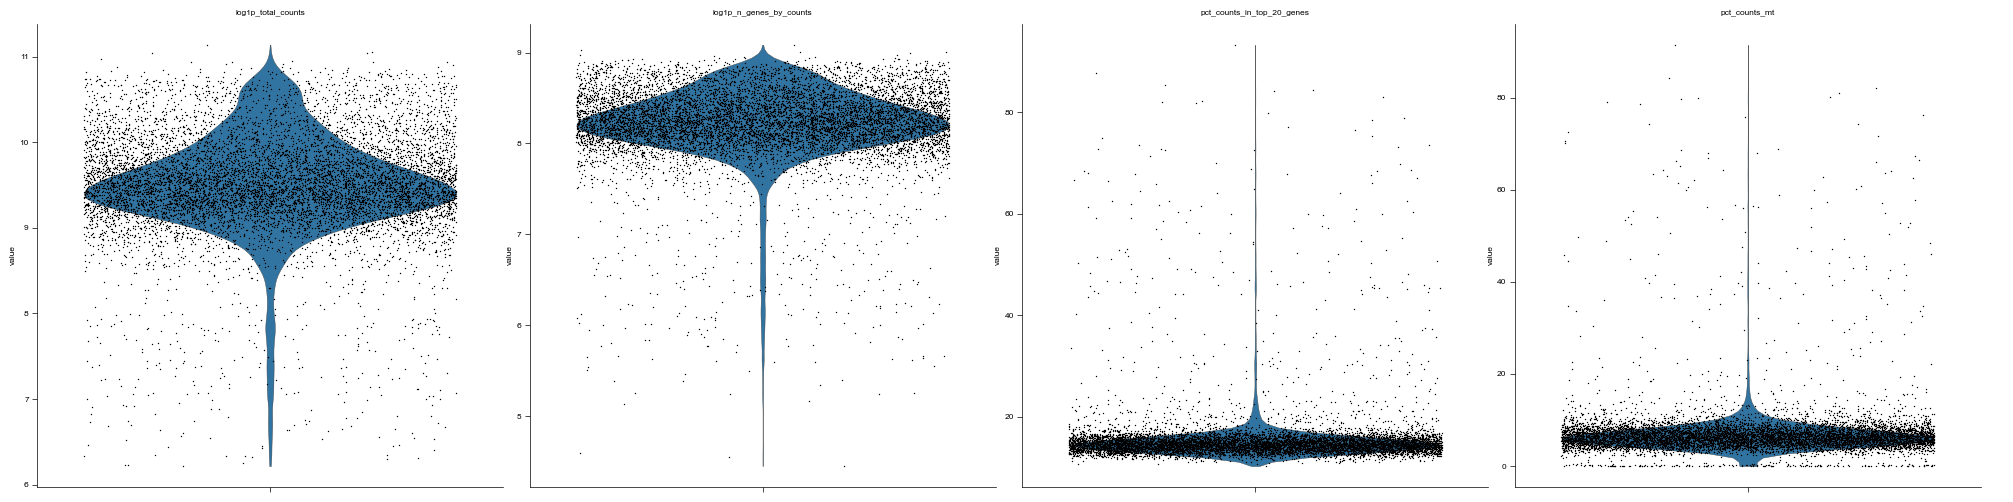

log1p_total_counts: 8.042427062988281 - 10.936771392822266
log1p_n_genes_by_counts: 7.285799992999117 - 9.198659789745346
pct_counts_in_top_20_genes: 9.876384917143344 - 19.157962942557603
pct_counts_mt: 2.368403434753418 - 10.020827293395996

Reading DKO Rep2
                   Reference_Annotation Seurat_Clusters_res.0.1
AAACCCAAGCCTGGAA-1             DKO Rep2                DKO Rep2
AAACCCAAGCTCGTGC-1             DKO Rep2                DKO Rep2
AAACCCACACCCTATC-1             DKO Rep2                DKO Rep2
AAACCCATCTCCCAAC-1             DKO Rep2                DKO Rep2
AAACCCATCTTGGCTC-1             DKO Rep2                DKO Rep2
...                                 ...                     ...
TTTGTTGCAAGCCCAC-1             DKO Rep2                DKO Rep2
TTTGTTGCACAGTACT-1             DKO Rep2                DKO Rep2
TTTGTTGTCACAACCA-1             DKO Rep2                DKO Rep2
TTTGTTGTCTATGTGG-1             DKO Rep2                DKO Rep2
TTTGTTGTCTTCGTGC-1             DKO 

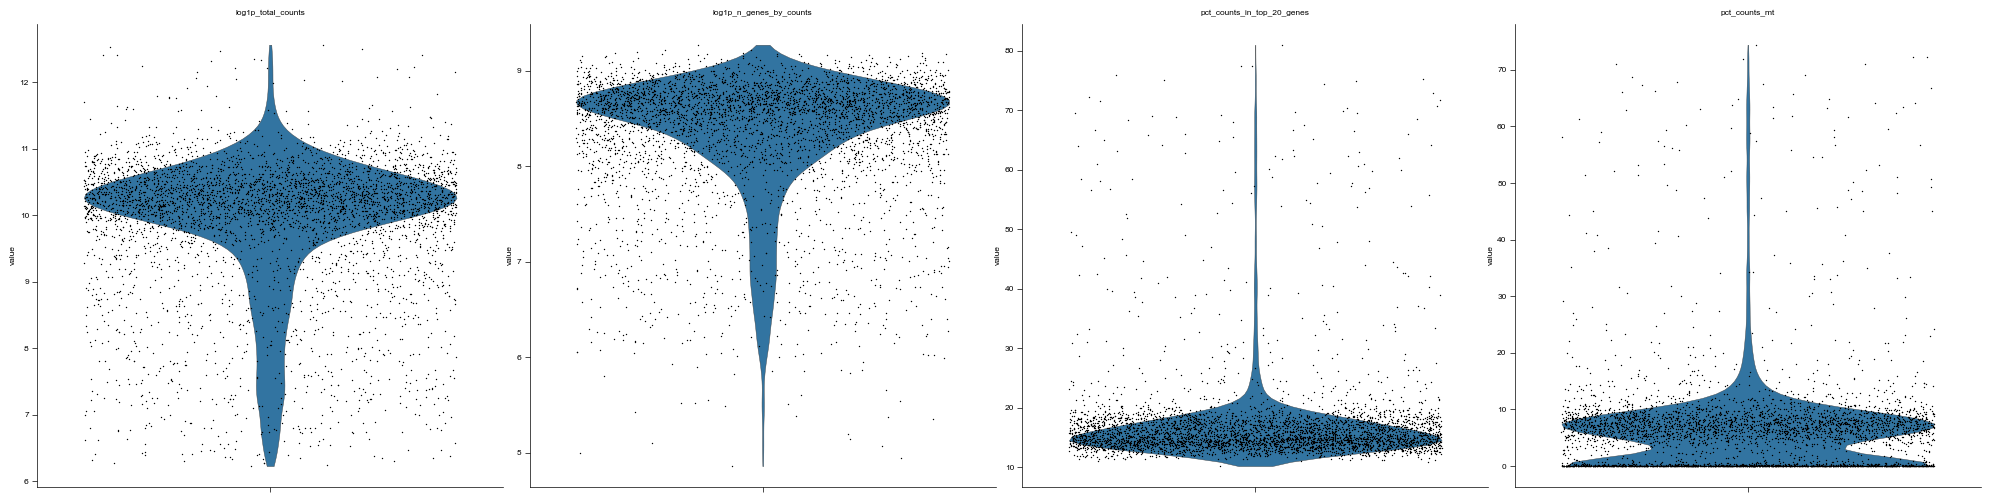

log1p_total_counts: 8.39741039276123 - 11.950457572937012
log1p_n_genes_by_counts: 7.343590951431482 - 9.769621436114663
pct_counts_in_top_20_genes: 7.368530869508904 - 23.222320464671526
pct_counts_mt: -4.99384880065918 - 16.88542938232422


In [20]:
#####################
# PROCESS DATA FROM NEW
#####################

adata = dict.fromkeys(sample_info["sample_name"])

# read all samples
for sample in adata.keys():
    print(f"\nReading {sample}")
    sample_path = sample_info.loc[sample_info['sample_name'] == sample, 'sample_path'].values[0]
    adata[sample] = sc_preprocess(sample_path, sample)

    sample_out_name = sample.replace(' ', '_').lower()
    path_out = f'/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/filtered_transcript_counts/{sample_out_name}.h5ad'
    adata[sample].write(path_out)

    

In [16]:
# grab all var DataFrames from our dictionary
all_var = [x.var for x in adata.values()]
# concatenate them
all_var = pd.concat(all_var, join="outer")
# remove duplicates
all_var = all_var[~all_var.index.duplicated()]

In [17]:
adata = sc.concat(adata, join="outer", label="sample_name", index_unique="-")

In [18]:
adata.var = all_var.loc[adata.var_names]

In [19]:
adata.obs = (
  adata.obs
  .merge(sample_info, how="left", on="sample_name")
  .set_axis(adata.obs.index)
)

In [20]:
adata.obs.drop(columns=['predicted_doublet'], inplace=True)

In [21]:
adata_concat = adata

In [22]:
print(adata_concat.obs)

                            Reference_Annotation Seurat_Clusters_res.0.1  \
AAACCCAAGACGACGT-1-WT Rep1               WT Rep1                 WT Rep1   
AAACCCATCATCGCTC-1-WT Rep1               WT Rep1                 WT Rep1   
AAACCCATCTCATTAC-1-WT Rep1               WT Rep1                 WT Rep1   
AAACGAAAGTGGTTCT-1-WT Rep1               WT Rep1                 WT Rep1   
AAACGAACACATGAAA-1-WT Rep1               WT Rep1                 WT Rep1   
...                                          ...                     ...   
TTTGGTTCAGTTCTAG-1-DKO Rep2             DKO Rep2                DKO Rep2   
TTTGTTGCACAGTACT-1-DKO Rep2             DKO Rep2                DKO Rep2   
TTTGTTGTCACAACCA-1-DKO Rep2             DKO Rep2                DKO Rep2   
TTTGTTGTCTATGTGG-1-DKO Rep2             DKO Rep2                DKO Rep2   
TTTGTTGTCTTCGTGC-1-DKO Rep2             DKO Rep2                DKO Rep2   

                             n_genes_by_counts  log1p_n_genes_by_counts  \
AAACCCAAGACG

In [23]:
###########################
# SCVI
###########################

sc.pp.normalize_total(adata_concat, target_sum=1e4)
sc.pp.log1p(adata_concat)
adata_concat.raw = adata_concat  # keep full dimension safe

mcfano_feature_selection(adata_concat, layer='counts', cv=None, verbose=1) # Fit CV

scvi.model.SCVI.setup_anndata(
    adata_concat,
    layer="counts",
    categorical_covariate_keys=["sample_source", "sample_name"]
)

scvi_model = scvi.model.SCVI(adata_concat)
scvi_model.train()

Using 0.01 for pvalue cutoff and 0.95 for mcfano quantile cutoff for highly variable genes.
After fitting, cv = 0.3


/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/nlaszik/venvs/bigsur/lib/python3.10/site-packa ...
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/nlaszik/venvs/bigsur/lib/python3.10/site-packa ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/nlaszik/venvs/bigsur/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention 

Epoch 330/330: 100%|██████████| 330/330 [15:42<00:00,  2.83s/it, v_num=1, train_loss_step=1.19e+4, train_loss_epoch=1.26e+4]

`Trainer.fit` stopped: `max_epochs=330` reached.


Epoch 330/330: 100%|██████████| 330/330 [15:42<00:00,  2.86s/it, v_num=1, train_loss_step=1.19e+4, train_loss_epoch=1.26e+4]


In [24]:
# ensure order is correct
adata_concat.obs["sample_name"] = adata_concat.obs["sample_name"].astype(
    pd.api.types.CategoricalDtype(categories=names, ordered=True)
)

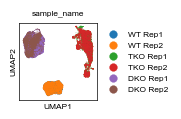

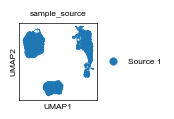

In [26]:
# regular plotting without scvi integration

sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata_concat, min_dist=0.3)

plot_umap(adata_concat, f'UMAP All Datasets No Integration {dataset}', "sample_name", num_cells=None, viewing=False)

plot_umap(adata_concat, f'UMAP All Datasets Source No Integration {dataset}', "sample_source", num_cells=None, viewing=False)

In [27]:
# Integrate SCVI Model Parameters
# This is already done in loaded data, no need to run again

SCVI_LATENT_KEY = "X_scVI"
adata_concat.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()

SCVI_NORMALIZED_KEY = "scvi_normalized"
adata_concat.layers[SCVI_NORMALIZED_KEY] = scvi_model.get_normalized_expression(library_size=10e4)

In [135]:
# map seurat categories, coming from the spontaneous diff 
celltype_to_category = {
    0: 'Pluripotent Cells',
    1: 'Early Ectoderm',
    2: 'Mesoderm',
    3: 'Neural Crest',
    4: 'Endoderm',
    5: 'Neurons',
    6: 'Endothelial',
    'WT Rep2': 'WT Rep2',
    'WT Rep1': 'WT Rep1',
    'TKO Rep2': 'TKO Rep2',
    'TKO Rep1': 'TKO Rep1',
}

# might need to make the orig mapping a string
adata_concat.obs["Seurat_Cluster"] = adata_concat.obs['Seurat_Clusters_res.0.1'].map(celltype_to_category)


                                  nCount_RNA  nFeature_RNA   individual  \
Batch1_Lane1_AAACCCAGTATCAGGG-EB        4394          1935  SNG-NA18858   
Batch1_Lane1_AAACCCATCGGAATGG-EB       14661          3857  SNG-NA18511   
Batch1_Lane1_AAACCCATCTTTGCTA-EB       26229          5498  SNG-NA18858   
Batch1_Lane1_AAACGAACAATTGAAG-EB        7502          2312  SNG-NA19160   
Batch1_Lane1_AAACGCTGTCAGCTTA-EB       22399          4806  SNG-NA18858   
...                                      ...           ...          ...   
Batch3_Lane4_TTTGGTTGTGAATGAT-EB        7724          2910  SNG-NA19160   
Batch3_Lane4_TTTGGTTTCGAAGCCC-EB       26242          4950  SNG-NA18511   
Batch3_Lane4_TTTGGTTTCGAGATAA-EB       26900          5257  SNG-NA18858   
Batch3_Lane4_TTTGTTGAGGATATAC-EB       17489          4683  SNG-NA18511   
Batch3_Lane4_TTTGTTGTCCTCTCGA-EB        5085          2184  SNG-NA18511   

                                      Rep_Lane Replicate  \
Batch1_Lane1_AAACCCAGTATCAGGG-EB  Batch

In [28]:
SCVI_LATENT_KEY = "X_scVI"

sc.tl.pca(adata_concat)
sc.pp.neighbors(adata_concat, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata_concat, min_dist=0.3)

In [32]:
# never change 1.2 for DKO-TKO-WT dataset
sc.tl.leiden(adata_concat, resolution=1.2)

# remap leiden clusters
# convert leiden clusters from string to int
cluster_1 = [20, 12, 17, 10, 19, 18, 3, 16]
clusters = adata_concat.obs["leiden"].astype(int)

mapping_dict = {}
for cluster in clusters:
    if cluster in cluster_1:
        mapping_dict[cluster] = 1
    else:
        mapping_dict[cluster] = 0

# apply mapping
adata_concat.obs["manual_clusters"] = clusters.map(mapping_dict)
adata_concat.obs["manual_clusters"] = adata_concat.obs["manual_clusters"].astype("category")

In [50]:
# for everything else, run this
sc.tl.leiden(adata_concat)
adata_concat.obs["manual_clusters"] = adata_concat.obs["leiden"]

In [ ]:
########
# SAVE
########
fn = f'scvi_integrated_{dataset}.h5ad'
adata_concat.write_h5ad(fn, compression='gzip')

In [59]:
celltype_to_category = {
    # --- Nervous system / ectoderm ---
    "Inhibitory neurons": "Ectoderm",
    "Excitatory neurons": "Ectoderm",
    "Inhibitory interneurons": "Ectoderm",
    "Granule neurons": "Ectoderm",
    "Purkinje neurons": "Ectoderm",
    "Visceral neurons": "Ectoderm",
    "ENS neurons": "Ectoderm",
    "Limbic system neurons": "Ectoderm",
    "Ganglion cells": "Ectoderm",
    "Retinal progenitors and Muller glia": "Ectoderm",
    "Photoreceptor cells": "Ectoderm",
    "Amacrine cells": "Ectoderm",
    "Horizontal cells": "Ectoderm",
    "Bipolar cells": "Ectoderm",
    "Unipolar brush cells": "Ectoderm",
    "Oligodendrocytes": "Ectoderm",
    "Astrocytes": "Ectoderm",
    "Schwann cells": "Ectoderm",
    "Microglia": "Ectoderm",
    "Retinal pigment cells": "Ectoderm",
    "Neuroendocrine cells": "Ectoderm",

    # --- Endoderm (gut, liver, pancreas, lung) ---
    "Goblet cells": "Endoderm",
    "Intestinal epithelial cells": "Endoderm",
    "Parietal and chief cells": "Endoderm",
    "Ciliated epithelial cells": "Endoderm",
    "Squamous epithelial cells": "Endoderm",
    "Hepatoblasts": "Endoderm",
    "AFP_ALB positive cells": "Endoderm",
    "Acinar cells": "Endoderm",
    "Islet endocrine cells": "Endoderm",
    "Ductal cells": "Endoderm",
    "MUC13_DMBT1 positive cells": "Endoderm",
    "IGFBP1_DKK1 positive cells": "Endoderm",
    "PDE11A_FAM19A2 positive cells": "Endoderm",
    "ELF3_AGBL2 positive cells": "Endoderm",
    "SLC24A4_PEX5L positive cells": "Endoderm",
    "CCL19_CCL21 positive cells": "Uncertain",
    "Corneal and conjunctival epithelial cells": "Ectoderm",

    # --- Mesoderm: cardiovascular, muscle, kidney, etc. ---
    "Cardiomyocytes": "Mesoderm",
    "Endocardial cells": "Mesoderm",
    "Epicardial fat cells": "Mesoderm",
    "Smooth muscle cells": "Mesoderm",
    "Skeletal muscle cells": "Mesoderm",
    "Stromal cells": "Mesoderm",
    "Mesothelial cells": "Mesoderm",
    "Stellate cells": "Mesoderm",
    "Hematopoietic stem cells": "Mesoderm",
    "Myeloid cells": "Mesoderm",
    "Antigen presenting cells": "Mesoderm",
    "Megakaryocytes": "Mesoderm",
    "Erythroblasts": "Mesoderm",
    "Thymocytes": "Mesoderm",
    "Thymic epithelial cells": "Uncertain",
    "Vascular endothelial cells": "Mesoderm",
    "Lymphatic endothelial cells": "Mesoderm",
    "Mesangial cells": "Mesoderm",
    "Metanephric cells": "Mesoderm",
    "Ureteric bud cells": "Mesoderm",
    "Chromaffin cells": "Mesoderm",
    "Adrenocortical cells": "Mesoderm",

    # --- Extra-embryonic / placental ---
    "Syncytiotrophoblasts and villous cytotrophoblasts": "Extra-embryonic",
    "Trophoblast giant cells": "Extra-embryonic",

    # --- Lens/eye ectodermal specializations ---
    "Lens fibre cells": "Ectoderm",

    # --- Misc / uncertain or technical ---
    "scHCL.hESC": "Pluripotent stem cell",
    "uncertain": "Uncertain",
    "WT Rep1": "WT",
    "WT Rep2": "WT",
    "TKO Rep1": "TKO",
    "TKO Rep2": "TKO",
}

adata.obs["germ_layer"] = adata.obs["Reference_Annotation"].map(celltype_to_category)

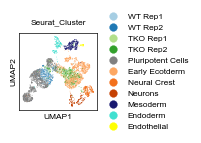

In [208]:
num_cells=5000
viewing=False

order = [
    'WT Rep1',
    'WT Rep2',
    'TKO Rep1',
    'TKO Rep2',
    'Pluripotent Cells',
    'Early Ecotderm',
    'Neural Crest',
    'Neurons',
    'Mesoderm',
    'Endoderm',
    'Endothelial'
]

adata_concat.obs["Seurat_Cluster"] = adata_concat.obs["Seurat_Cluster"].astype(
    pd.api.types.CategoricalDtype(categories=order, ordered=True)
)

neuron_cmap = cm.get_cmap('Oranges')
neuron_shades = [neuron_cmap(i) for i in [0.4, 0.6, 0.8]]  # Lighter to darker or vice versa
palette = list(cmaps['Paired'].colors[:4]) + [mcolors.CSS4_COLORS['grey']] + neuron_shades + [mcolors.CSS4_COLORS['midnightblue']] + [mcolors.CSS4_COLORS['turquoise']] + [mcolors.CSS4_COLORS['yellow']]

plot_umap(adata_concat, f'UMAP Sample Name {dataset}', 'Seurat_Cluster', num_cells=num_cells, viewing=viewing, palette=palette)




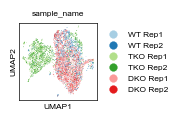

In [12]:
# Plot!
viewing=False
num_cells=5000

#viewing=True
#num_cells=None

adata_sampled = sc.pp.subsample(adata_concat, n_obs=num_cells, copy=True)

plot_umap(adata_sampled, f'UMAP {dataset}', "sample_name", num_cells=None, viewing=viewing, palette=palette)
#plot_umap(adata_concat, f'UMAP All Datasets {dataset}', "sample_name", num_cells=None, viewing=viewing, palette=palette)
#plot_umap(adata_concat, f'UMAP Focused Datasets {dataset}', "sample_name", num_cells=None, viewing=viewing, groups=['WT Rep1', 'TKO Rep1', 'NSC Day 11', 'NSC Day 18', 'Neural Day 6'], palette=palette)

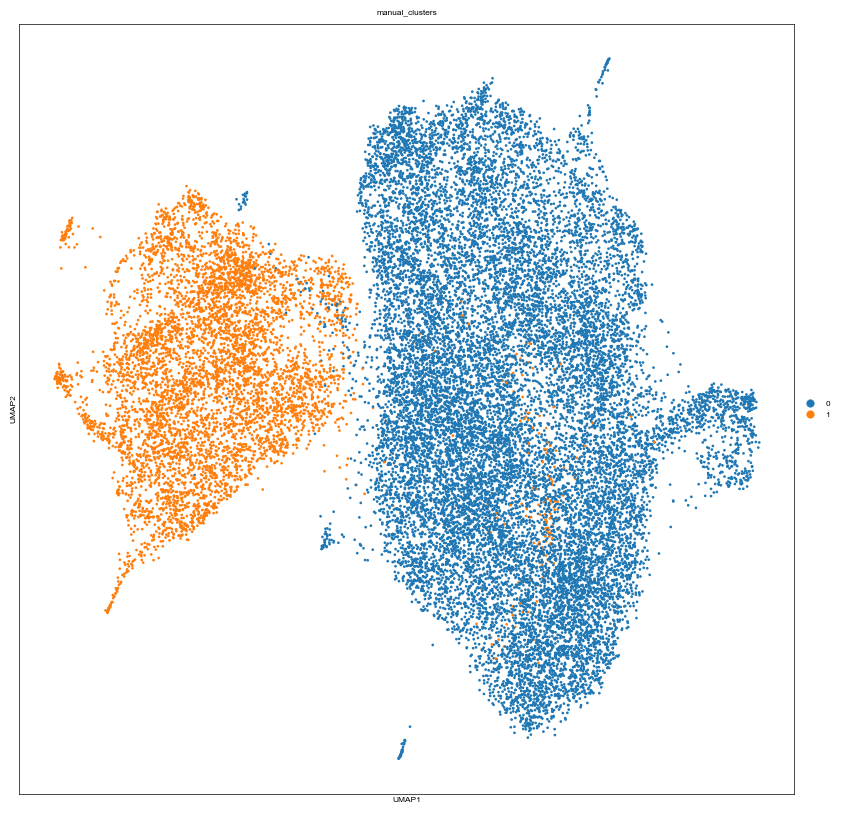

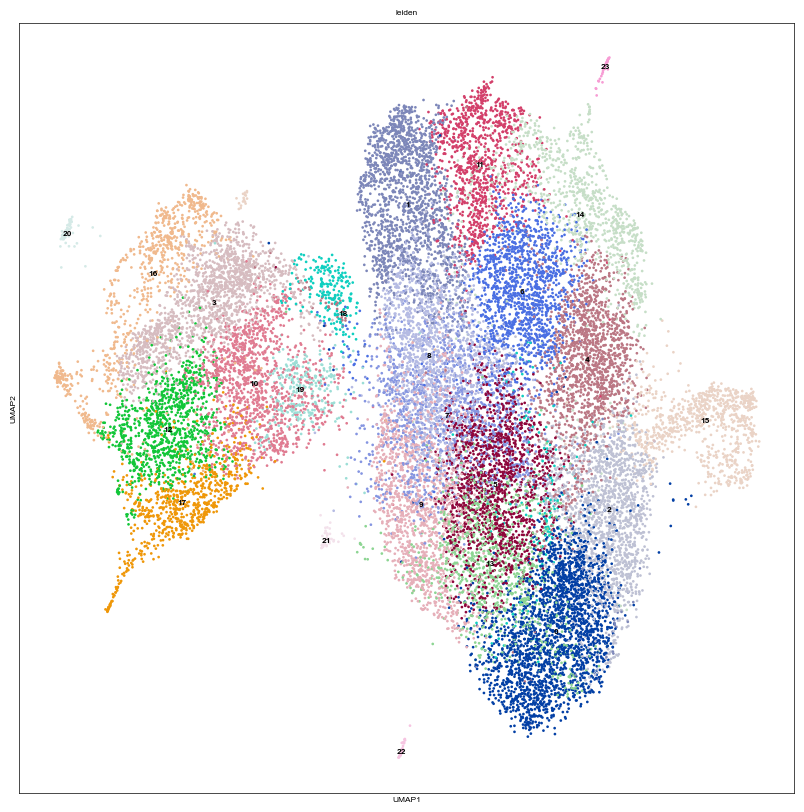

In [33]:
viewing=True

#plot_pca(adata_sampled, f'PCA1_2 {dataset}', 'sample_name', num_cells=None, viewing=viewing, dimensions=[0,1])
#plot_pca(adata_sampled, f'PCA1_2 {dataset}', 'manual_clusters', num_cells=None, viewing=viewing, dimensions=[0,1])

#legend_loc="on data"
#plot_umap(adata_sampled, f'UMAP Sample Name {dataset}', 'sample_name', num_cells=None, viewing=viewing)
plot_umap(adata_concat, f'UMAP Clusters {dataset}', 'manual_clusters', num_cells=None, viewing=viewing)
plot_umap(adata_concat, f'UMAP Clusters {dataset}', 'leiden', num_cells=None, viewing=viewing, legend_loc="on data")

#plot_umap(adata_sampled, f'UMAP Cell Type {dataset}', 'germ_layer', num_cells=None, viewing=viewing)

NRGN


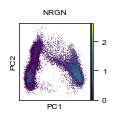

DIO3


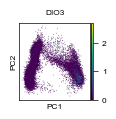

IGF2


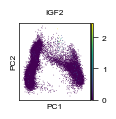

RP9P


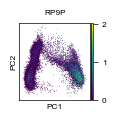

ADAMTS9


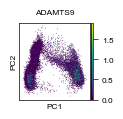

OSR1


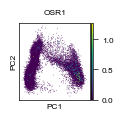

TFAP2A


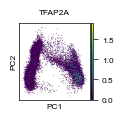

POU3F3


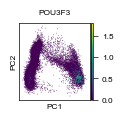

GDF7


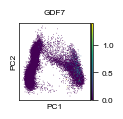

GATA2


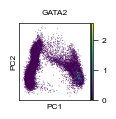

FGF9


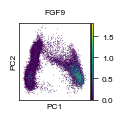

PDZRN4


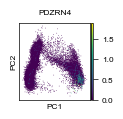

ZNF503-AS2


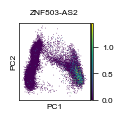

CCDC92


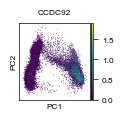

FOXC1


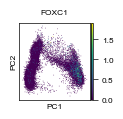

EN1


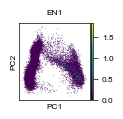

MEIS1


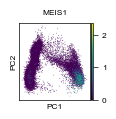

CNTFR


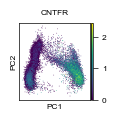

FZD10


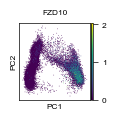

EBF1


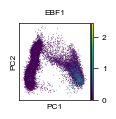

OLIG2


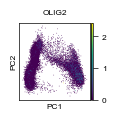

HOTAIRM1


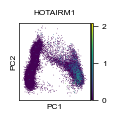

KCNC1


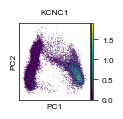

SP9


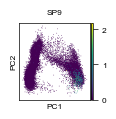

C1orf194


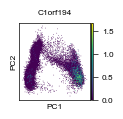

FZD10-AS1


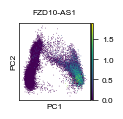

ZBTB16


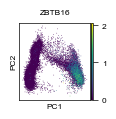

TBX1


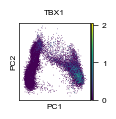

SLC18A3


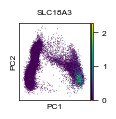

EFCC1


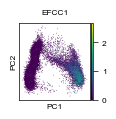

In [12]:
genes = ['FST', 'PTN', 'PODXL2', 'POU5F1', 'NR2F2', 'TRIM2', 'OTX2']

genes = ['POU5F1', 'NR2F2', 'HAND1', 'SOX17', 'PAX6', 'OTX2']

genes = ['POU5F1', 'ZBTB16', 'EFCC1', 'FZD10-AS1', 'CNTFR', 'CUEDC1', 'MAGI2-AS3', 'FZD10', 'FRZB', 'NPAS3', 'NR2F1-AS1', 'NRGN', 'SCD5']

genes = ['NRGN', 'DIO3', 'IGF2', 'RP9P', 'ADAMTS9', 'OSR1', 'TFAP2A', 'POU3F3', 'GDF7', 'GATA2', 'FGF9', 'PDZRN4', 'ZNF503-AS2', 'CCDC92', 'FOXC1', 'EN1', 'MEIS1', 'CNTFR', 'FZD10', 'EBF1', 'OLIG2', 'HOTAIRM1', 'KCNC1', 'SP9', 'C1orf194', 'FZD10-AS1', 'ZBTB16', 'TBX1', 'SLC18A3', 'EFCC1']

viewing=False

for gene in genes:
    print(gene)
    plot_pca(adata_concat, f'PCA1_2 {dataset}', gene, num_cells=None, viewing=viewing, dimensions=[0,1])
    #plot_umap(adata_sampled, f'UMAP Leiden {dataset}', gene, num_cells=None, viewing=viewing)

In [12]:
#######################
# START ENRICHMENT HERE
#######################

sc.tl.dendrogram(adata_concat, groupby='manual_clusters')
sc.tl.rank_genes_groups(adata_concat, groupby="manual_clusters", method="wilcoxon")

In [13]:
df_top_genes = sc.get.rank_genes_groups_df(adata_concat, group="1")

In [14]:
print(df_top_genes)

         names      scores  logfoldchanges  pvals  pvals_adj
0          PTN  111.041687        5.111313    0.0        0.0
1       TUBA1A  108.253250        2.266942    0.0        0.0
2         PRTG  107.032440        5.486869    0.0        0.0
3       IGDCC3  105.466827        3.373196    0.0        0.0
4        ACAT2  103.105827        2.701596    0.0        0.0
...        ...         ...             ...    ...        ...
30026     ESRG -111.841988       -6.485599    0.0        0.0
30027    SNHG5 -112.086594       -2.875473    0.0        0.0
30028    TERF1 -112.549225       -3.448020    0.0        0.0
30029     UGP2 -112.922577       -3.969860    0.0        0.0
30030  MIR302B -113.219856       -5.431477    0.0        0.0

[30031 rows x 5 columns]


      names      scores  logfoldchanges  pvals  pvals_adj #chrom        start  \
0       PTN  111.041687        5.111313    0.0        0.0   chr7  137018479.0   
1    TUBA1A  108.253250        2.266942    0.0        0.0  chr12   49572863.0   
2      PRTG  107.032440        5.486869    0.0        0.0  chr15   56025350.0   
3    IGDCC3  105.466827        3.373196    0.0        0.0  chr15   65660340.0   
4     ACAT2  103.105827        2.701596    0.0        0.0   chr6  160173077.0   
..      ...         ...             ...    ...        ...    ...          ...   
223  DNAJC7   50.678932        0.657049    0.0        0.0  chr17   40159457.0   
224    GYPC   50.594696        1.470497    0.0        0.0   chr2  127403734.0   
225   SOX11   50.578880        0.908811    0.0        0.0   chr2    5822516.0   
226    AFF3   50.360645        4.715595    0.0        0.0   chr2  100749052.0   
227   EFNA5   50.116505        2.264515    0.0        0.0   chr5  106996638.0   

            stop    length 

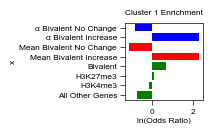

In [15]:
df_merged = pd.merge(df_top_genes, df_promoter_type, how='left', left_on='names', right_on='gene')

df_merged['In Cluster 1'] = df_merged['scores'] > 50

print(df_merged.loc[df_merged['In Cluster 1'] == True])

######
cat_2_name = 'In Cluster 1'

######

cats = [
    ['Combined TKO ZR Residual Class', 'TKO MeanFC Class', 'No Change'],
    ['Combined TKO MeanFC Class', 'TKO ZR Residual Class', 'No Change'],
    ['Promoter Class', False, False]
]

df_bar_records = []

for cat in cats:
    
    cat_1_name = cat[0]

    if cat[1]:
        df_filt = df_merged.copy()
        #df_filt = df_merged.loc[df_merged['Promoter Class'] == 'Bivalent']
        #df_filt = df_merged.loc[df_merged[cat[1]] == cat[2]]
    else:
        df_filt = df_merged.copy()
        
    df_filt = df_filt.dropna(subset=[cat_1_name])
    df_filt = df_filt.loc[~df_filt[cat_1_name].str.contains('0')]
    
    print(len(df_filt.index))
    
    cats_1 = list(set(df_filt[cat_1_name]))
    cats_2 = list(set(df_filt[cat_2_name]))
    
    for category_1 in cats_1:
        
        for category_2 in cats_2:
            
            a = len(df_filt.loc[(df_filt[cat_1_name] == category_1) & (df_filt[cat_2_name] == category_2)].index)
            b = len(df_filt.loc[(df_filt[cat_1_name] == category_1) & (df_filt[cat_2_name] != category_2)].index)
            c = len(df_filt.loc[(df_filt[cat_1_name] != category_1) & (df_filt[cat_2_name] == category_2)].index)
            d = len(df_filt.loc[(df_filt[cat_1_name] != category_1) & (df_filt[cat_2_name] != category_2)].index)
    
            if c == 0 or b == 0:
                continue
            
            log_odds_ratio = np.log((a * d) / (b * c))
            
            p = stats.fisher_exact([[a, c], [b, d]], alternative='two-sided').pvalue

            if 'ZR' in cat_1_name:
                cat_1_plot_name = 'α '
            elif 'Mean' in cat_1_name:
                cat_1_plot_name = 'Mean '
            else:
                cat_1_plot_name = ''
    
            if category_2 and log_odds_ratio != -np.inf:
                print(f'{category_1}\t{category_2}\t{a}')
                print(df_filt.loc[(df_filt[cat_1_name] == category_1) & (df_filt[cat_2_name] == category_2)][['gene', 'residual_diff_tko', 'MeanLog2FC_tko']])
                df_bar_records.append({'x': f'{cat_1_plot_name}{category_1}', 'ln(Odds Ratio)': log_odds_ratio, 'P(Fisher)': p})

df_bar = pd.DataFrame(df_bar_records)
print(df_bar)

fig, ax = plt.subplots(figsize=(1,1))

palette = ['green', 'green', 'green', 'green', 'red', 'red', 'blue', 'blue']

order = [
    'α Bivalent No Change',
    'α Bivalent Increase',
    'Mean Bivalent No Change',
    'Mean Bivalent Increase',
    'Bivalent',
    'H3K27me3',
    'H3K4me3',
    'All Other Genes'
]

sns.barplot(data=df_bar, y='x', x='ln(Odds Ratio)', ax=ax, order=order)
#plt.xticks(rotation=45, ha='right')

patches = ax.patches
sorted_patches = sorted(patches, key=lambda p: p.get_tightbbox().y0)
for i, patch in enumerate(sorted_patches):
    patch.set_facecolor(palette[i])

plt.title('Cluster 1 Enrichment')
plt.show()

fig.savefig('figures/log_odds_various_groupings.svg')
    

In [42]:
# group by sample name to see if unique genes are expressed in any of the datasets (specifically TKO)
sc.tl.dendrogram(adata_concat, groupby='sample_name')
sc.tl.rank_genes_groups(adata_concat, groupby="sample_name", method="wilcoxon")

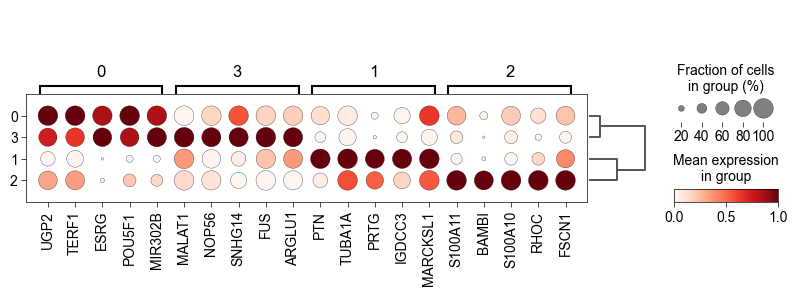

In [21]:
rc('font', size=12)    # fontsize of the tick labels
sc.pl.rank_genes_groups_dotplot(adata_concat, n_genes=5, standard_scale="var")

0 0
0 1
1 0
1 1
2 0


/tmp/ipykernel_2122869/1054354959.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i_x, i_y].set_xticklabels(axs[i_x, i_y].get_xticklabels(), ha='right')


2 1


/tmp/ipykernel_2122869/1054354959.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i_x, i_y].set_xticklabels(axs[i_x, i_y].get_xticklabels(), ha='right')


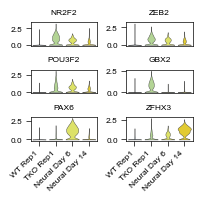

In [12]:
adata_sampled = adata_concat

# ESC genes
#genes = ["POU5F1", 'NANOG', 'SOX2']

# not a TF: 'CDH2', 'LSAMP'

# genes that are sequentially upregulated, limit to TFs
#genes = ['SOX5', 'NPAS3', 'PAX6']

# genes out of order yo
#genes = ['VIM', 'NEFM', 'MARCKS', 'DLK1', 'PTN', 'TAGLN3', 'LIX1']
#genes = ['POU3F2', 'NR2F1']

genes = ['POU3F2', 'NR2F2', 'MN1', 'LHX2', 'ZEB2', 'NRGN', 'PAX6', 'CBX4', 'GBX2', 'ZFHX3', 'GIT1', 'NPAS3', 'FZD2']

genes = ['NR2F2', 'ZEB2', 'POU3F2', 'GBX2', 'PAX6', 'ZFHX3']

# uninteresting genes
#genes = ['TUBA1A', 'TTYH1', 'OTX2']

# mesoderm genes?
#genes = ['HAND1', 'T', 'FOXC1', 'FOXF1', 'GSC', 'MIXL1', 'NODAL']
#order=['WT Rep1', 'TKO Rep1', 'EC Day 0', 'EC Day 6']

#neural_type = 'brain'
#order=['WT Rep1', 'TKO Rep1', 'NSC Day 4', 'NSC Day 18', 'NSC Day 31']

#neural_type = 'eb'
#order=['EB', 'WT Rep1', 'TKO Rep1']

neural_type = 'nerve'
order=['WT Rep1', 'TKO Rep1', 'Neural Day 6', 'Neural Day 14']

#sc.pl.stacked_violin(adata_sub, genes, categories_order=order, groupby="sample_name")

fig, axs = plt.subplots(3, 2)

fig.set_size_inches(2, 2)

for i, color in enumerate(genes):
    
    i_x = i // 2
    i_y = i % 2

    print(i_x, i_y)
    
    sc.pl.violin(adata_sampled, color, order=order, groupby="sample_name", ax=axs[i_x, i_y], show=False, size=0.25, rotation=45, stripplot=False)

    axs[i_x, i_y].set_ylabel('')

    axs[i_x, i_y].set_title(color)
    
    if i_x < 2:
        axs[i_x, i_y].set_xticks([])
    else:
        axs[i_x, i_y].set_xticklabels(axs[i_x, i_y].get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig(f'figures/gene_violin_plots_{neural_type}.svg')
plt.show()

categories: WT Rep1, WT Rep2, TKO Rep1, etc.
var_group_labels: Stem Cell, Tubule, Neural, etc.


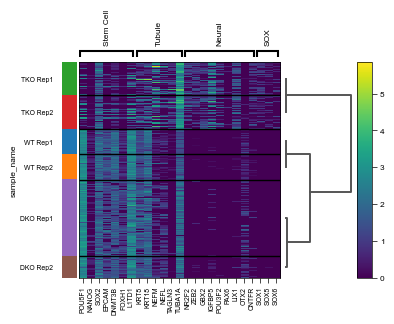

In [16]:
marker_genes_dict = {
    
    'Stem Cell':[
        'POU5F1', 'NANOG', 'SOX2', 'EPCAM', 'DNMT3B', 'FOXH1', 'L1TD1'
    ],
    
    'Tubule':
    [
        'KRT8', 'KRT18', 'NEFM', 'NEFL', 'TAGLN3', 'TUBA1A'
    ],
    
    'Neural':
    [
        'NR2F2', 'ZEB2', 'GBX2', 'IGFBP5', 'POU3F2', 'PAX6', 'LIX1', 'OTX2', 'CNTFR'
    ],

    'SOX':
    [
        'SOX1', 'SOX5', 'SOX6'
    ]
    
}

# bad genes, don't show much interesting things: MARCKS, KRT19, FOXA1, FOXA2, SOX17, PODXL, TUBA1B, TUBA1A

adata_concat.obs["manual_clusters"] = adata_concat.obs["manual_clusters"].astype("str")

#path_svg = os.path.join(path_out_dir, f'integrated_heatmap.svg')
#standard_scale='var'
path_svg = 'figures'
sc.pl.heatmap(
    adata_concat,
    marker_genes_dict,
    groupby="sample_name",
    cmap="viridis",
    dendrogram=True,
    save=f'integrated_heatmap_{dataset}.svg',
    figsize=(4,3)
)